In [19]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoost
import time
import matplotlib.pyplot as plt
import joblib

In [20]:
# Load the combined datasets (just for label checking)
df_test_combined = pd.read_csv("datasets/combined_test.csv")
df_train_combined = pd.read_csv("datasets/combined_train.csv")

# Load the df_test with latent features for model inference
df_test = pd.read_csv("datasets/df_test.csv")

feature_cols = ['latent_0', 'latent_1', 'latent_2', 'latent_3', 'latent_4', 'recon_loss', 'kld_loss']
X_test = df_test[feature_cols].values

booster = xgb.Booster()
booster.load_model("models/xgboost_model.json")
dtest = xgb.DMatrix(X_test)

start_time = time.time()
y_pred = booster.predict(dtest)
inference_time = time.time() - start_time

num_samples = len(X_test)
avg_time_per_sample = inference_time / num_samples

print(f"=== XGBoost ===")
print(f"Total inference time: {inference_time:.4f} seconds")
print(f"Number of samples: {num_samples}")
print(f"Average time per sample: {avg_time_per_sample*1000:.4f} ms")

=== XGBoost ===
Total inference time: 1.5762 seconds
Number of samples: 101001
Average time per sample: 0.0156 ms


In [21]:
print("=== Label Distribution ===")
print(f"\nClasses present in combined_train: {len(df_train_combined['Label'].unique())}")
print(f"Classes present in combined_test: {len(df_test_combined['Label'].unique())}")

print(f"\nUnique labels in combined_train: {sorted(df_train_combined['Label'].unique())}")
print(f"Unique labels in combined_test: {sorted(df_test_combined['Label'].unique())}")

print(f"\nLabel counts in combined_train:")
print(df_train_combined['Label'].value_counts().sort_index())

print(f"\nLabel counts in combined_test:")
print(df_test_combined['Label'].value_counts().sort_index())

=== Label Distribution ===

Classes present in combined_train: 5
Classes present in combined_test: 3

Unique labels in combined_train: ['Benign', 'DoS attacks-GoldenEye', 'DoS attacks-Slowloris', 'FTP-BruteForce', 'SSH-Bruteforce']
Unique labels in combined_test: ['Benign', 'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP']

Label counts in combined_train:
Label
Benign                   1663721
DoS attacks-GoldenEye      41508
DoS attacks-Slowloris      10990
FTP-BruteForce            193360
SSH-Bruteforce            187589
Name: count, dtype: int64

Label counts in combined_test:
Label
Benign                  360842
DDOS attack-HOIC        686012
DDOS attack-LOIC-UDP      1730
Name: count, dtype: int64


In [22]:
lgb_booster = lgb.Booster(model_file="models/lightgbm_model.txt")

start_time = time.time()
y_pred_lgb = lgb_booster.predict(X_test)
inference_time_lgb = time.time() - start_time

avg_time_per_sample_lgb = inference_time_lgb / num_samples

print(f"\n=== LightGBM ===")
print(f"Total inference time: {inference_time_lgb:.4f} seconds")
print(f"Number of samples: {num_samples}")
print(f"Average time per sample: {avg_time_per_sample_lgb*1000:.4f} ms")


=== LightGBM ===
Total inference time: 0.1730 seconds
Number of samples: 101001
Average time per sample: 0.0017 ms


In [23]:
catboost_model = CatBoost()
catboost_model.load_model("models/catboost_model.json", format="json")

start_time = time.time()
y_pred_cat = catboost_model.predict(X_test)
inference_time_cat = time.time() - start_time

avg_time_per_sample_cat = inference_time_cat / num_samples

print(f"\n=== CatBoost ===")
print(f"Total inference time: {inference_time_cat:.4f} seconds")
print(f"Number of samples: {num_samples}")
print(f"Average time per sample: {avg_time_per_sample_cat*1000:.4f} ms")


=== CatBoost ===
Total inference time: 0.0449 seconds
Number of samples: 101001
Average time per sample: 0.0004 ms


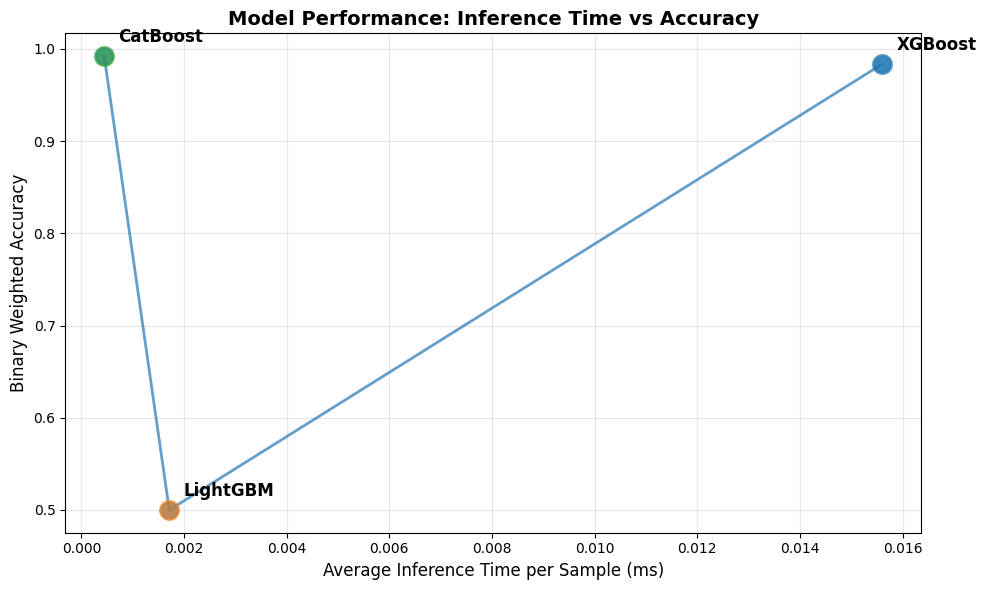


=== Summary (Sorted by Inference Time) ===
CatBoost: 0.0004 ms/sample, Accuracy: 0.9923
LightGBM: 0.0017 ms/sample, Accuracy: 0.4999
XGBoost: 0.0156 ms/sample, Accuracy: 0.9837


In [24]:
models = ['XGBoost', 'LightGBM', 'CatBoost']
inference_times = [avg_time_per_sample * 1000, avg_time_per_sample_lgb * 1000, avg_time_per_sample_cat * 1000]
accuracies = [0.9837, 0.4999, 0.9923]

data = list(zip(models, inference_times, accuracies))
data_sorted = sorted(data, key=lambda x: x[1])

models_sorted = [x[0] for x in data_sorted]
times_sorted = [x[1] for x in data_sorted]
acc_sorted = [x[2] for x in data_sorted]

plt.figure(figsize=(10, 6))
plt.plot(times_sorted, acc_sorted, 'o-', linewidth=2, markersize=12, alpha=0.7)

colors = {'XGBoost': '#1f77b4', 'LightGBM': '#ff7f0e', 'CatBoost': '#2ca02c'}
for i, model in enumerate(models_sorted):
    plt.scatter(times_sorted[i], acc_sorted[i], s=200, alpha=0.6, c=colors[model], zorder=5)
    plt.annotate(model, (times_sorted[i], acc_sorted[i]), 
                xytext=(10, 10), textcoords='offset points', fontsize=12, fontweight='bold')

plt.xlabel('Average Inference Time per Sample (ms)', fontsize=12)
plt.ylabel('Binary Weighted Accuracy', fontsize=12)
plt.title('Model Performance: Inference Time vs Accuracy', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Summary (Sorted by Inference Time) ===")
for i, model in enumerate(models_sorted):
    print(f"{model}: {times_sorted[i]:.4f} ms/sample, Accuracy: {acc_sorted[i]:.4f}")

In [25]:
print("\n=== Training Performance")
print(f"XGBoost: {0.9419100631750144:.4f}")
print(f"LightGBM: {0.9975049861848595:.4f}")
print(f"CatBoost: {0.9113762995364114:.4f}")


=== Training Performance
XGBoost: 0.9419
LightGBM: 0.9975
CatBoost: 0.9114
